# CML vs BIDS Comparison

Using `bids_validation` package with `BIDSReader`.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import os
import numpy as np
import pandas as pd
import cmlreaders as cml
import matplotlib.pyplot as plt
%matplotlib inline

from eeg_validation import (
    EventsPipeline,
    RawSignalPipeline,
    EpochedPipeline,
    MontagePipeline,
)
from eeg_validation.io import load_and_concat
from eeg_validation.plotting import plot_comparison_results

pd.options.display.max_rows = 100
pd.options.display.max_columns = 50


## 1. Configuration

In [3]:
# ---- Shared settings ----
REL_START = 200      # ms
REL_STOP  = 500     # ms
BUFFER_MS = 500     # ms
tmin = -BUFFER_MS
tmax = REL_STOP + BUFFER_MS

MAX_SUBJECTS = 10
SUBJECTS_TO_EXCLUDE = {"LTP001", "LTP9992", "LTP9993"}

# Set to True to skip sessions whose output CSVs already exist
SKIP_IF_EXISTS = True


---
## 2. Scalp / LTP Comparisons

### 2a. Select subjects & sessions

In [3]:
ltp_experiments = ["ValueCourier"]
ltp_bids_root   = "/data/LTP_BIDS/"
ltp_out_path    = "ltp_results/"

df = cml.get_data_index()
df_exp = df[df["experiment"].isin(ltp_experiments)].copy()
df_exp = df_exp[~df_exp["subject"].isin(SUBJECTS_TO_EXCLUDE)]

dfs = []
for exp in ltp_experiments:
    df_this = df_exp[df_exp["experiment"] == exp]
    subjects = df_this["subject"].drop_duplicates().sort_values().head(MAX_SUBJECTS)
    dfs.append(df_this[df_this["subject"].isin(subjects)])

df_ltp = pd.concat(dfs, ignore_index=True)
print(f"LTP jobs: {len(df_ltp)} sessions across {df_ltp['subject'].nunique()} subjects")
df_ltp[["subject", "experiment", "session"]].head(20)


LTP jobs: 28 sessions across 8 subjects


,subject,experiment,session
0,LTP606,ValueCourier,0
1,LTP606,ValueCourier,1
2,LTP606,ValueCourier,2
3,LTP606,ValueCourier,3
4,LTP606,ValueCourier,4
5,LTP606,ValueCourier,5
6,LTP607,ValueCourier,0
7,LTP607,ValueCourier,1
8,LTP607,ValueCourier,2
9,LTP607,ValueCourier,3


### 2b. Run Raw + Epoched EEG comparisons

In [ ]:
for _, row in df_ltp.iterrows():
    sub, exp, sess = row["subject"], row["experiment"], int(row["session"])
    bids_root = ltp_bids_root

    # --- Raw (scalp: no acquisition) ---
    try:
        result = RawSignalPipeline(
            sub, exp, sess, bids_root, ltp_out_path,
            skip_if_exists=SKIP_IF_EXISTS,
        ).run()
        tag = "SKIP" if result.get("skipped") else "DONE"
        print(f"[{tag}] Raw  | {sub} | {exp} | {sess}")
    except Exception as e:
        print(f"[FAIL] Raw  | {sub} | {exp} | {sess}: {e}")

    # --- Epoched (scalp: no acquisition) ---
    try:
        result = EpochedPipeline(
            sub, exp, sess, bids_root, ltp_out_path,
            skip_if_exists=SKIP_IF_EXISTS,
            tmin=tmin, tmax=tmax, verbose=True,
        ).run()
        tag = "SKIP" if result.get("skipped") else "DONE"
        print(f"[{tag}] Epoch | {sub} | {exp} | {sess}")
    except Exception as e:
        print(f"[FAIL] Epoch | {sub} | {exp} | {sess}: {e}")

### 2c. Run Behavioral Events comparison

In [5]:
for _, row in df_ltp.iterrows():
    sub, exp, sess = row["subject"], row["experiment"], int(row["session"])

    try:
        result = EventsPipeline(
            sub, exp, sess, ltp_bids_root, ltp_out_path,
            skip_if_exists=SKIP_IF_EXISTS,
        ).run()
        tag = "SKIP" if result.get("skipped") else "DONE"
        print(f"[{tag}] Events | {sub} | {exp} | {sess}: {result.get('reason')}")
    except Exception as e:
        print(f"[FAIL] Events | {sub} | {exp} | {sess}: {e}")


0         23440
1         31922
2        468068
3        646089
4        646183
         ...   
237    10769845
238    10769847
239    10774076
240    10774082
241    10774084
Name: sample, Length: 242, dtype: int64
[DONE] Events | LTP606 | ValueCourier | 0: None
0         26913
1         35692
2         40775
3         44050
4         46917
         ...   
322    11185152
323    11185154
324    11188636
325    11188640
326    11188642
Name: sample, Length: 327, dtype: int64
[DONE] Events | LTP606 | ValueCourier | 1: None
0          1870
1          4027
2          5323
3          5831
4          6755
         ...   
304    10513236
305    10513236
306    10518356
307    10518362
308    10518364
Name: sample, Length: 309, dtype: int64
[DONE] Events | LTP606 | ValueCourier | 2: None
0        17126
1        19110
2        20114
3        20931
4        21477
        ...   
316    9440931
317    9440931
318    9444682
319    9444687
320    9444687
Name: sample, Length: 321, dtype: int64
[DO

### 2d. Aggregate LTP results & plot

In [6]:
ltp_final = "ltp_final/"
os.makedirs(ltp_final, exist_ok=True)

FILE_CATEGORIES = [
    "df_raw", "df_raw_summary", "df_raw_time",
    "df_behavior_summary",
    "df_epoch", "df_epoch_summary", "df_epoch_time",
]

ltp_dfs = {}
for cat in FILE_CATEGORIES:
    files = [
        os.path.join(dp, f)
        for dp, _, fns in os.walk(ltp_out_path)
        for f in fns
        if f.endswith(".csv") and f.startswith(cat + "_")
    ]
    if not files:
        print(f"Skipping {cat} (no files)")
        continue
    df_all = load_and_concat(files)
    ltp_dfs[cat] = df_all
    outfile = os.path.join(ltp_final, f"{cat}_all.csv")
    df_all.to_csv(outfile, index=False)
    print(f"{cat}: {len(files)} files -> {outfile}")


df_raw: 63 files -> ltp_final/df_raw_all.csv
df_raw_summary: 21 files -> ltp_final/df_raw_summary_all.csv
df_raw_time: 21 files -> ltp_final/df_raw_time_all.csv
df_behavior_summary: 24 files -> ltp_final/df_behavior_summary_all.csv
Removed 31409 duplicate rows
df_epoch: 99 files -> ltp_final/df_epoch_all.csv
Removed 21 duplicate rows
df_epoch_summary: 25 files -> ltp_final/df_epoch_summary_all.csv
df_epoch_time: 24 files -> ltp_final/df_epoch_time_all.csv


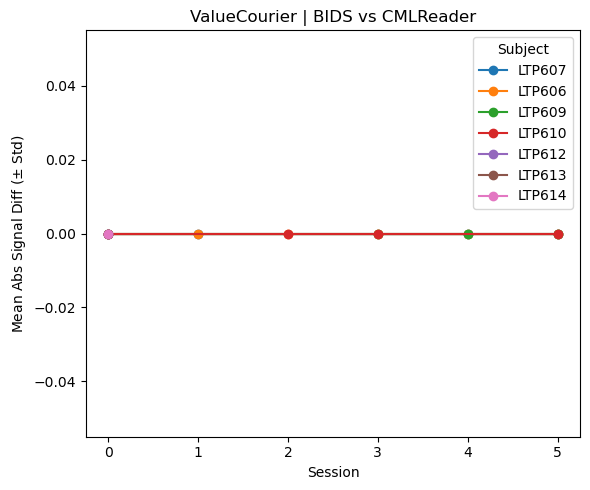

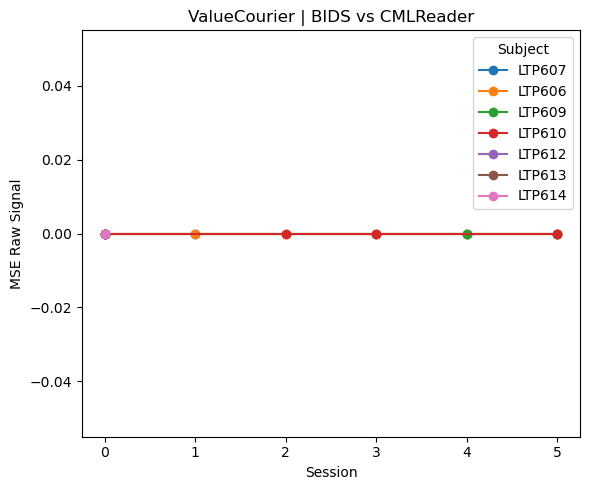

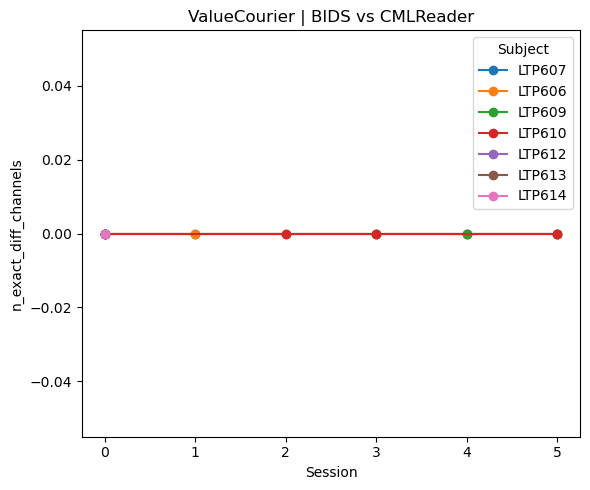

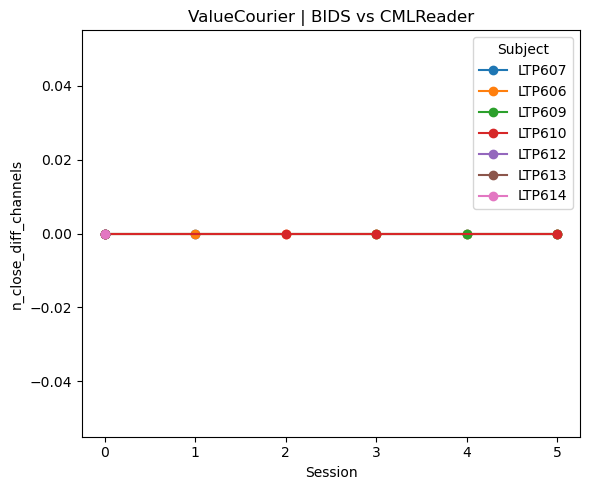

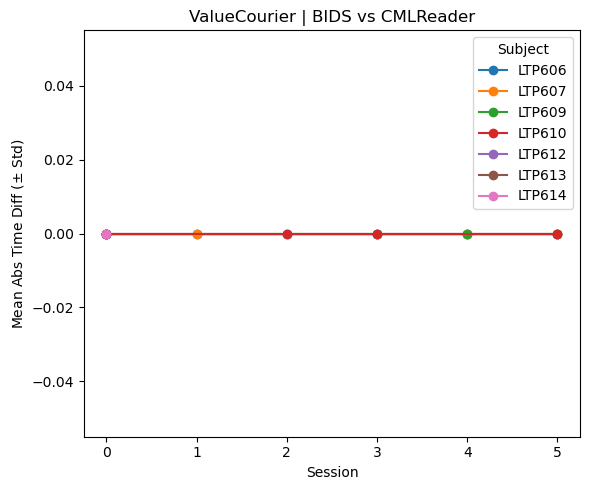

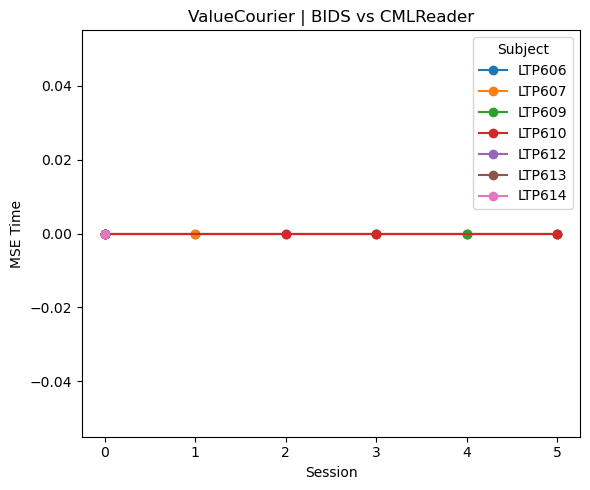

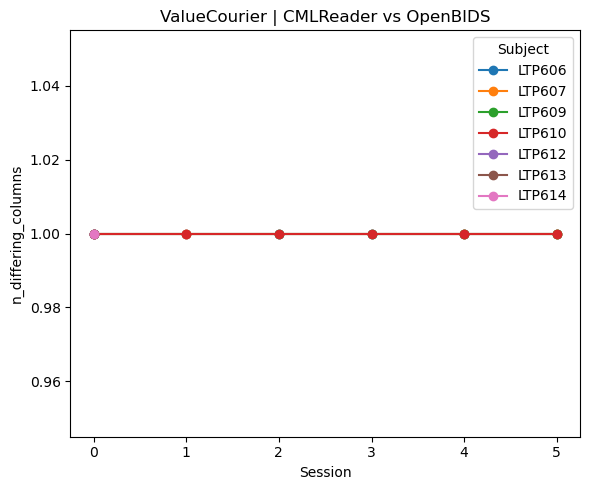

In [7]:
# --- Raw signal plots ---
if "df_raw_summary" in ltp_dfs:
    plot_comparison_results(ltp_dfs["df_raw_summary"], "mean_abs_diff", "std_diff", col_label="Mean Abs Signal Diff")
    plot_comparison_results(ltp_dfs["df_raw_summary"], "mse", col_label="MSE Raw Signal")
    plot_comparison_results(ltp_dfs["df_raw_summary"], "n_exact_diff_channels")
    plot_comparison_results(ltp_dfs["df_raw_summary"], "n_close_diff_channels")

# --- Time coord plots ---
if "df_raw_time" in ltp_dfs:
    plot_comparison_results(ltp_dfs["df_raw_time"], "mean_abs_time_diff", "std_time_diff", col_label="Mean Abs Time Diff")
    plot_comparison_results(ltp_dfs["df_raw_time"], "mse_time", col_label="MSE Time")

# --- Behavioral plots ---
if "df_behavior_summary" in ltp_dfs:
    plot_comparison_results(ltp_dfs["df_behavior_summary"], "n_differing_columns")


---
## 3. iEEG / RAM Comparisons

### 3a. Select subjects & sessions

In [4]:
ram_experiments = ["FR1"]
ram_bids_root   = "/data/LTP_BIDS/FR1"
ram_out_path    = "ram_results_unit_convert/"

ram_subjects_to_include = [
    'R1060M', 'R1061T', 'R1065J', 'R1066P', 'R1092J',
    'R1108J', 'R1111M', 'R1207J', 'R1226D', 'R1230J',
    'R1236J', 'R1243T', 'R1247P', 'R1292E', 'R1308T',
    'R1310J', 'R1328E', 'R1332M', 'R1334T', 'R1337E',
    'R1341T', 'R1354E', 'R1395M', 'R1542J',
]

df = cml.get_data_index()
df_exp = df[df["experiment"].isin(ram_experiments)].copy()
df_exp = df_exp[~df_exp["subject"].isin(SUBJECTS_TO_EXCLUDE)]
df_exp = df_exp[df_exp["subject"].isin(ram_subjects_to_include)]

dfs = []
for exp in ram_experiments:
    df_this = df_exp[df_exp["experiment"] == exp]
    subjects = df_this["subject"].drop_duplicates().sort_values().head(MAX_SUBJECTS)
    dfs.append(df_this[df_this["subject"].isin(subjects)])

df_ram = pd.concat(dfs, ignore_index=True)
print(f"RAM jobs: {len(df_ram)} sessions across {df_ram['subject'].nunique()} subjects")
df_ram[["subject", "experiment", "session", "localization", "montage"]].head(20)


RAM jobs: 39 sessions across 10 subjects


,subject,experiment,session,localization,montage
0,R1060M,FR1,0,0,0
1,R1060M,FR1,1,0,0
2,R1060M,FR1,2,0,0
3,R1060M,FR1,3,0,0
4,R1061T,FR1,0,0,0
5,R1061T,FR1,1,0,0
6,R1061T,FR1,2,0,0
7,R1061T,FR1,3,0,0
8,R1065J,FR1,0,0,0
9,R1065J,FR1,1,0,0


### 3b. Run Raw + Epoched EEG comparisons (iEEG)

In [ ]:
for _, row in df_ram.iterrows():
    sub, exp, sess = row["subject"], row["experiment"], int(row["session"])
    loc = int(row["localization"])
    mon = int(row["montage"])

    for acq in ["contacts", "pairs"]:
        # --- Raw ---
        try:
            result = RawSignalPipeline(
                sub, exp, sess, ram_bids_root, ram_out_path,
                skip_if_exists=SKIP_IF_EXISTS,
                localization=loc, montage=mon,
                acquisition=acq,
            ).run()
            tag = "SKIP" if result.get("skipped") else "DONE"
            print(f"[{tag}] Raw/{acq}  | {sub} | {exp} | {sess}")
        except Exception as e:
            print(f"[FAIL] Raw/{acq}  | {sub} | {exp} | {sess}: {e}")

        # --- Epoched ---
        try:
            result = EpochedPipeline(
                sub, exp, sess, ram_bids_root, ram_out_path,
                skip_if_exists=SKIP_IF_EXISTS,
                localization=loc, montage=mon,
                acquisition=acq,
                tmin=tmin, tmax=tmax,
            ).run()
            tag = "SKIP" if result.get("skipped") else "DONE"
            print(f"[{tag}] Epoch/{acq} | {sub} | {exp} | {sess}")
        except Exception as e:
            print(f"[FAIL] Epoch/{acq} | {sub} | {exp} | {sess}: {e}")

### 3c. Run Behavioral Events comparison (iEEG)

In [ ]:
for _, row in df_ram.iterrows():
    sub, exp, sess = row["subject"], row["experiment"], int(row["session"])
    loc = int(row["localization"])
    mon = int(row["montage"])

    try:
        result = EventsPipeline(
            sub, exp, sess, ram_bids_root, ram_out_path,
            skip_if_exists=SKIP_IF_EXISTS,
            localization=loc, montage=mon,
        ).run()
        tag = "SKIP" if result.get("skipped") else "DONE"
        print(f"[{tag}] Events | {sub} | {exp} | {sess}")
    except Exception as e:
        print(f"[FAIL] Events | {sub} | {exp} | {sess}: {e}")


### 3d. Run Montage comparison (iEEG only)

In [ ]:
for _, row in df_ram.iterrows():
    sub, exp, sess = row["subject"], row["experiment"], int(row["session"])
    loc = int(row["localization"])
    mon = int(row["montage"])

    for acq in ["contacts", "pairs"]:
        try:
            result = MontagePipeline(
                sub, exp, sess, ram_bids_root, ram_out_path,
                skip_if_exists=SKIP_IF_EXISTS,
                localization=loc, montage=mon,
                acquisition=acq,
            ).run()
            tag = "SKIP" if result.get("skipped") else "DONE"
            print(f"[{tag}] Montage/{acq} | {sub} | {exp} | {sess}")
        except Exception as e:
            print(f"[FAIL] Montage/{acq} | {sub} | {exp} | {sess}: {e}")

### 3e. Aggregate RAM results & plot

In [ ]:
ram_final = "ram_final/"
os.makedirs(ram_final, exist_ok=True)

FILE_CATEGORIES_RAM = [
    "df_raw", "df_raw_summary", "df_time",
    "df_behavior_summary",
    "df_epoch", "df_epoch_summary", "df_epoch_time",
    "df_contacts_summary", "df_contacts_column_summary", "df_contacts_mismatches",
    "df_pairs_summary", "df_pairs_column_summary", "df_pairs_mismatches",
    "df_montage_summary",
]

ram_dfs = {}
for cat in FILE_CATEGORIES_RAM:
    files = [
        os.path.join(dp, f)
        for dp, _, fns in os.walk(ram_out_path)
        for f in fns
        if f.endswith(".csv") and f.startswith(cat + "_")
    ]
    if not files:
        print(f"Skipping {cat} (no files)")
        continue
    df_all = load_and_concat(files)
    ram_dfs[cat] = df_all
    outfile = os.path.join(ram_final, f"{cat}_all.csv")
    df_all.to_csv(outfile, index=False)
    print(f"{cat}: {len(files)} files -> {outfile}")


In [ ]:
# --- Raw signal plots ---
if "df_raw_summary" in ram_dfs:
    plot_comparison_results(ram_dfs["df_raw_summary"], "mean_abs_diff", "std_diff", col_label="Mean Abs Signal Diff", title="Raw Signal Mean Difference")
    plot_comparison_results(ram_dfs["df_raw_summary"], "mse", col_label="MSE Raw Signal", title="Raw Signal MSE")
    plot_comparison_results(ram_dfs["df_raw_summary"], "n_exact_diff_channels", title="Raw Signal Number of Differing EEG Channels (No Tolerance)")
    plot_comparison_results(ram_dfs["df_raw_summary"], "n_close_diff_channels", title="Raw Signal Number of Differing EEG Channels (Tolerance)")

# --- Time coord plots ---
if "df_time" in ram_dfs:
    plot_comparison_results(ram_dfs["df_time"], "mean_abs_time_diff", "std_time_diff", col_label="Mean Abs Time Diff", title="Time Indices Mean Difference")
    plot_comparison_results(ram_dfs["df_time"], "mse_time", col_label="MSE Time", title="Time Indices MSE")

# --- Behavioral plots ---
if "df_behavior_summary" in ram_dfs:
    plot_comparison_results(ram_dfs["df_behavior_summary"], "n_differing_columns", title="Events Number of Differing Columns")
